#**Feature Scaling**

Standardization is a part of Feature Scaling. **What is Feature Scaling?**

* Feature Scaling is a technique to standardize the independent features present in the data in a fixed range.

* It basically brings the data to the same range to make better predictions and outcomes.

**Why do we need Feature Scaling?**

We need feature scaling because while using and working with ML models we need the independent variables to be close or in a certain range so that the logic of the ML model can be applied correctly.

Also, when the data is not in the same scale, it is very difficult to compare the data and think of an possibly correct outcome even in problems like regression.

**Types of Feature Scaling:**

* Standardization

* Normalization (minmax scaler and robust scaler)

#**Standardization**

* It is also known as Z-score Normalization.

*  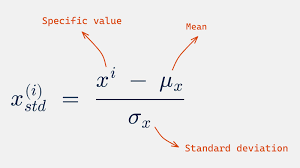

* A fact about standardized values is when we get a value for each element in the feature after appyling standardization, the mean of the new column formed will be **zero** and the standard deviation will be **1**.

* Another important point is, when the data is standardized the data in the plot gets closer to the origin because the mean becomes zero, also the size of the data is reduced from all the axes to 1 because the standard deviation is 1. 

* The shifting of data towards the origin due to mean being zero is called as **Mean centric data**.

* If the Standard deviation is 1 or more, the size of the data reduces or squeeses and if it is 0.5, the size of the data would rather increse.

## Code:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('./Social_Network_Ads.csv')

In [3]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
#train test split
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(df.drop('Purchased',axis=1),
                                                       df['Purchased'],test_size=0.3,random_state=0)

x_train.shape , x_test.shape

((280, 2), (120, 2))

In [5]:
#standard scalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler into the train data, it will learn the parameters
scaler.fit(x_train)

#transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

Inference to the code: 
* we are fitting the standard scaler to the train data and the formula x' = x - mean / standard deviation is being applied to every poin of x train data and the data is tranformed and is being stored into the variable x_train_scaled, same goes for x test.

* we fit scaler only to the train data, but transformation is done in both, train and test data. 

In [6]:
scaler.mean_ #mean of age and salary

array([3.78642857e+01, 6.98071429e+04])

In [7]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

After the transformation, the data is being returned in the form of a numpy array. so, we again need to convert it to dataframe

In [8]:
#converting array to DataFrame

x_train_scaled = pd.DataFrame(x_train_scaled , columns = x_train.columns )
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns )

In [9]:
x_train_scaled #we can see that the values are scaled now.

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [10]:
#describing the statistics for x_train data
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [11]:
#describing the statistics for x_train_scaled data
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


**Inference:** We can clearly compare the statistics for x_train data and x_train_scaled data. The x_train_data is scaled and it can be seen that its mean is 0 and standard deviation is 1 whereas mean in x_train data is 37.9 and the standard deviation is 10.2

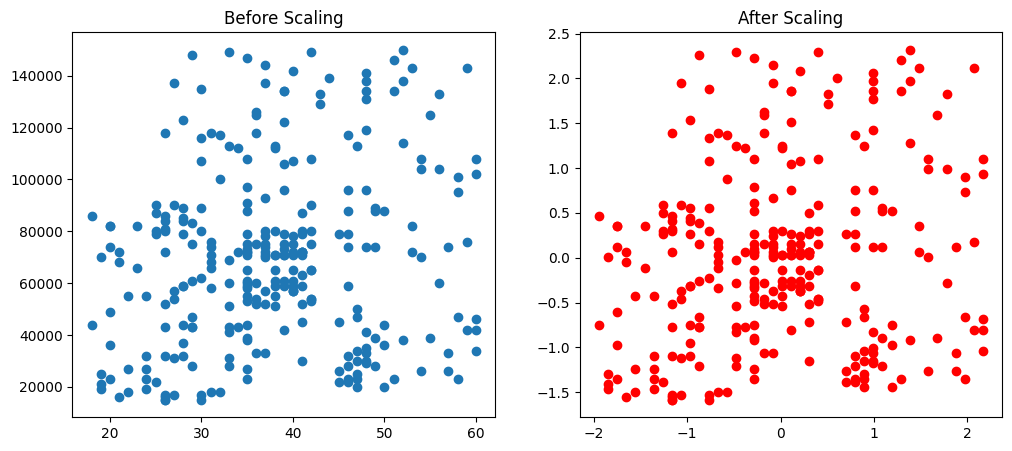

In [12]:
#effect of scaling
fig, (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color = 'red')
ax2.set_title('After Scaling')
plt.show()


Inference: We can see that the data in plot 1 has a huge scale of age and salary but in the plot 2, the data has been scaled and it has been centered to origin due to the mean being 0.

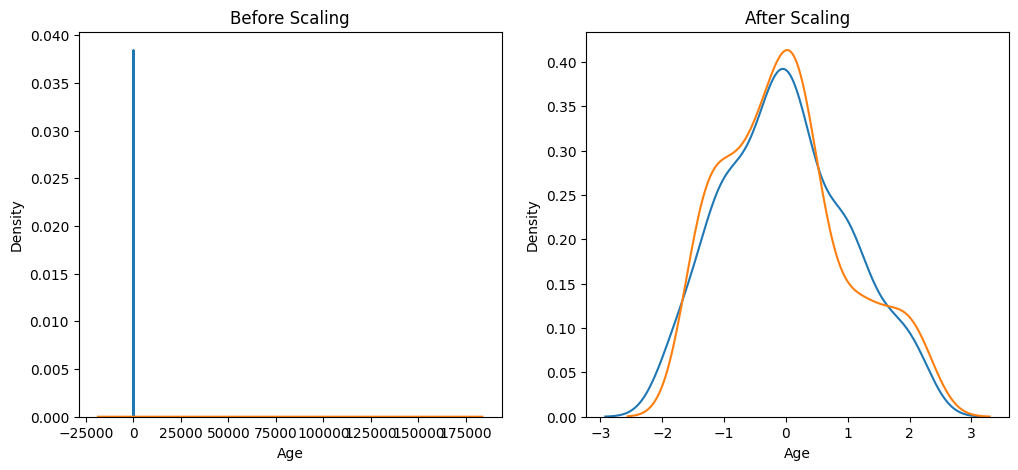

In [13]:
fig, (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Age'],ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2)

plt.show()

**Inference:** In the first plot the line is parallel because the age and salary are on different scales and they are incomparable. Whereas, after scaling the comparision between age and salary is possible and graphs are nearly the same in variaition.

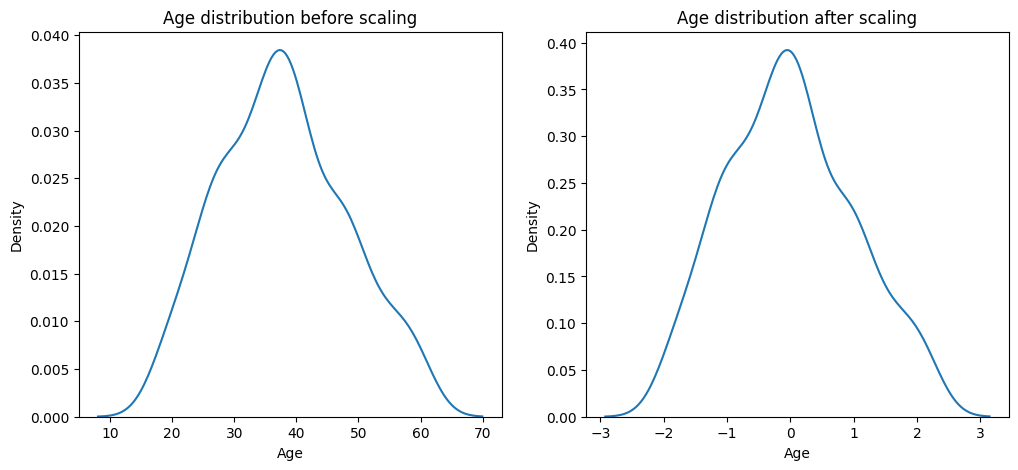

In [14]:
#comparision of distributions
fig,(ax1, ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title('Age distribution before scaling')
sns.kdeplot(x_train['Age'],ax=ax1)

#after scaling
ax2.set_title('Age distribution after scaling')
sns.kdeplot(x_train_scaled['Age'],ax=ax2)
plt.show()

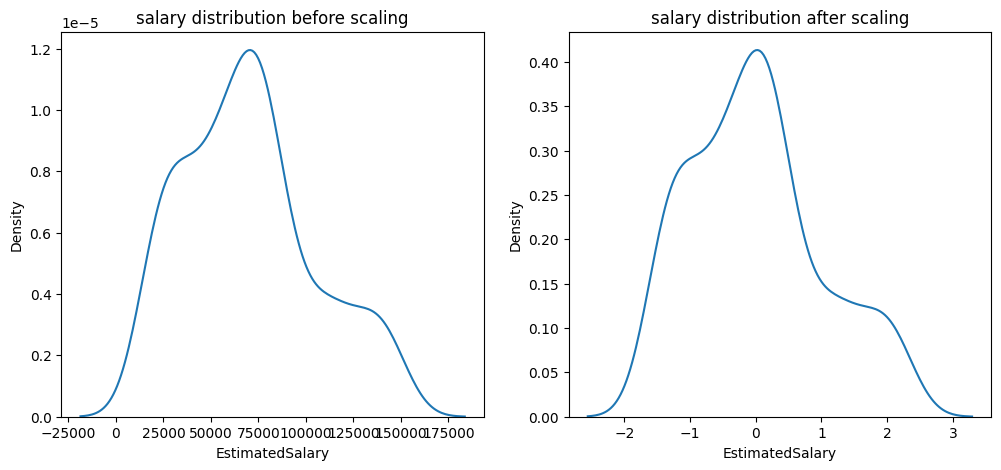

In [15]:
#comparision of distributions
fig,(ax1, ax2) = plt.subplots(ncols=2 , figsize=(12,5))

#before scaling
ax1.set_title('salary distribution before scaling')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)

#after scaling
ax2.set_title('salary distribution after scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

**Inference:** We can see that even after scaling, the distirbution of the data is same, that means standardization does not impact the distribution of the data.

**Why is scaling important?**

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [18]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
print('Actual',accuracy_score(y_test,y_pred))
print('Scaled',accuracy_score(y_test, y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


**Inference**: The accuarcy of the scaled data actually increases in the Logistic Regression model as compared to the non scaled data.

In [22]:
#there is no effect of scaling on Decision Tree algorithm
from sklearn.tree import DecisionTreeClassifier

In [23]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [24]:
dt.fit(x_train , y_train)
dt_scaled.fit(x_train_scaled , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [25]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [26]:
print('Actual',accuracy_score(y_test,y_pred))
print('Scaled',accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


Also, there is no effect of outliers on scaling and vice versa.

**When to use Standardization?**

We must blindly apply standardization while using these algoritms:


1.   K-Means
2.   K-Nearest Neighbors
3.   Principal Component Analysis
4.   Artificial Nueral Network
5.   Gradient Descent



**When is Standardization not needed much?**


1.   Decision Tree
2.   Random Forest
3.   Gradient Boost
4.   XG Boost

